In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("data/advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200, 5)


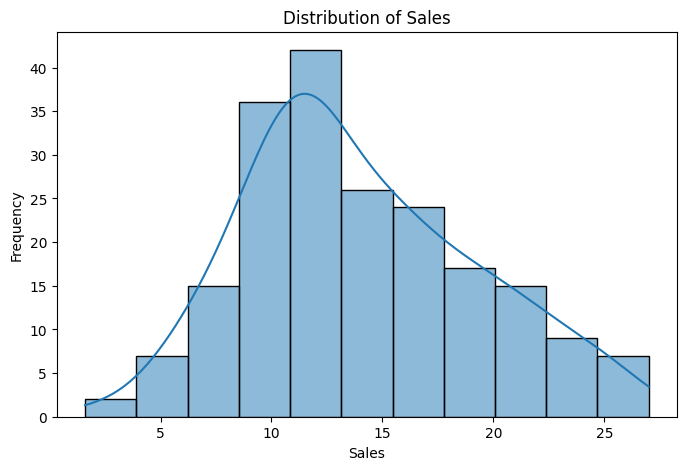

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

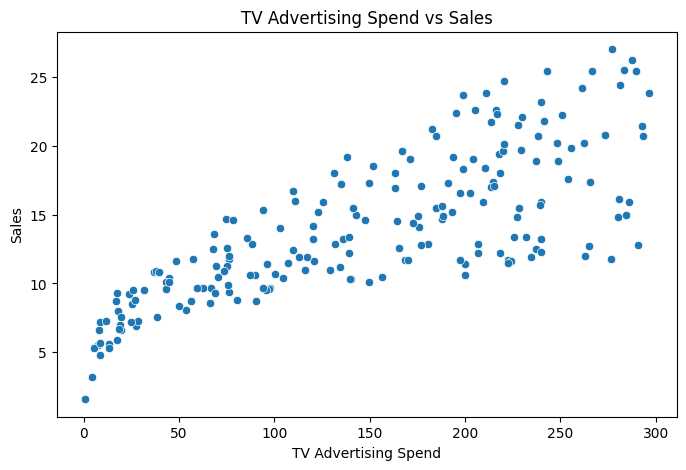

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

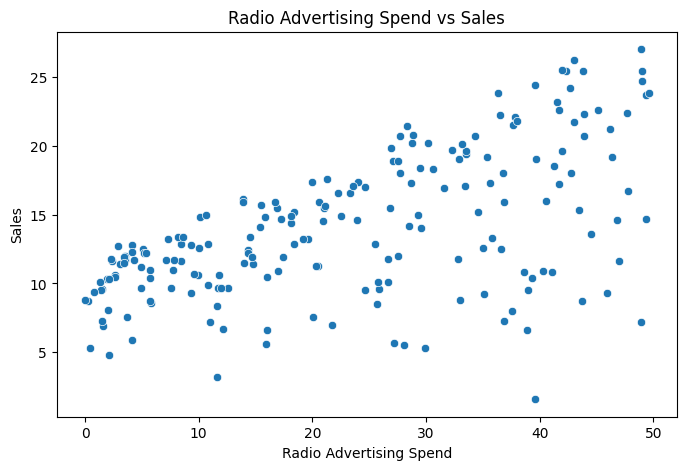

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Radio Advertising Spend vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

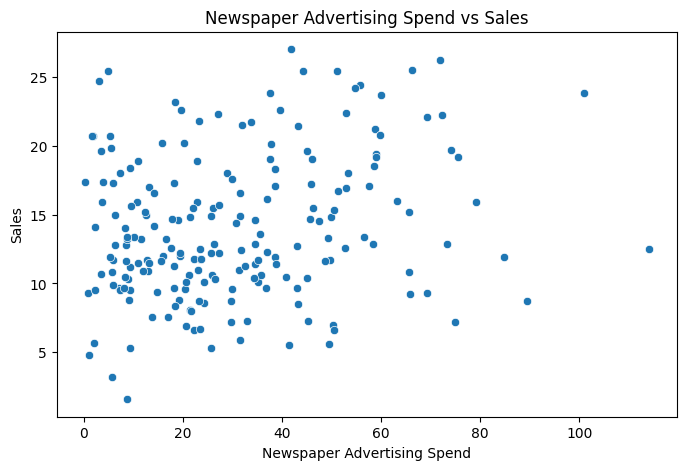

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Newspaper Advertising Spend vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

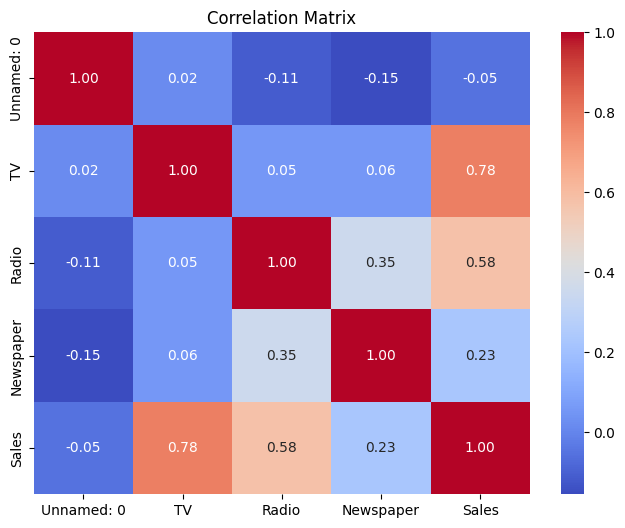

In [15]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [16]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [18]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [19]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


In [20]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [21]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
--------------------
MAE : 0.9850000000000001
RMSE: 1.4747881203752624
R²  : 0.9310914968293178


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
--------------------
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R²  : 0.9812843792541843


In [24]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Decision Tree,0.985000,1.474788,0.931091
2,Random Forest,0.620100,0.768591,0.981284


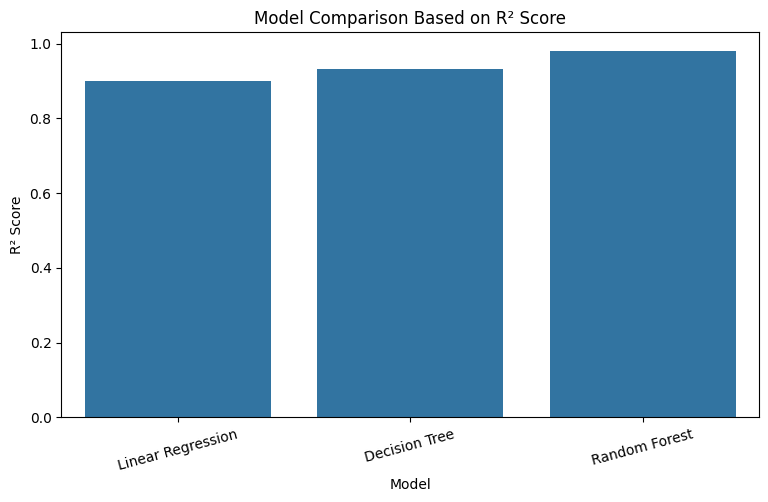

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(data=results, x="Model", y="R2 Score")

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


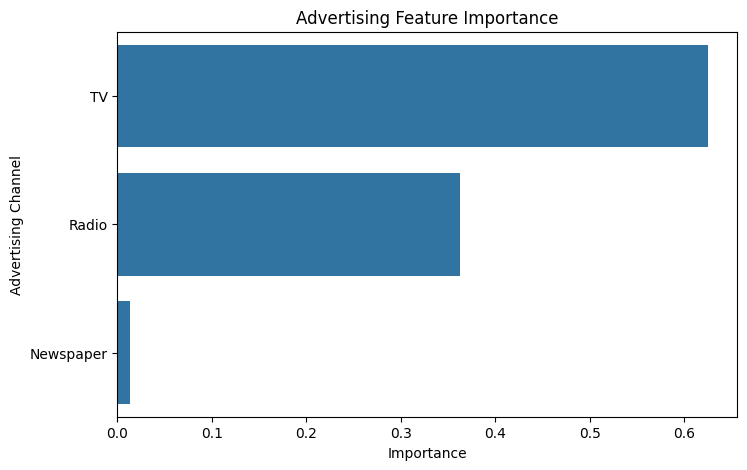

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

Predict future sales

We can give the model new advertising spending values.

For example:

TV = 150
Radio = 30
Newspaper = 20

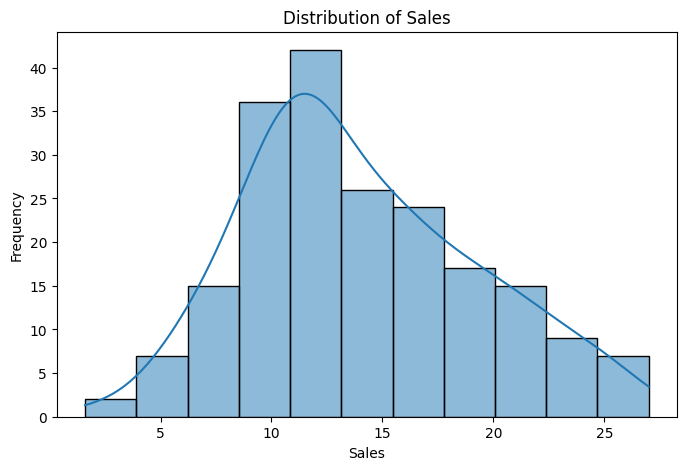

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [29]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.628
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


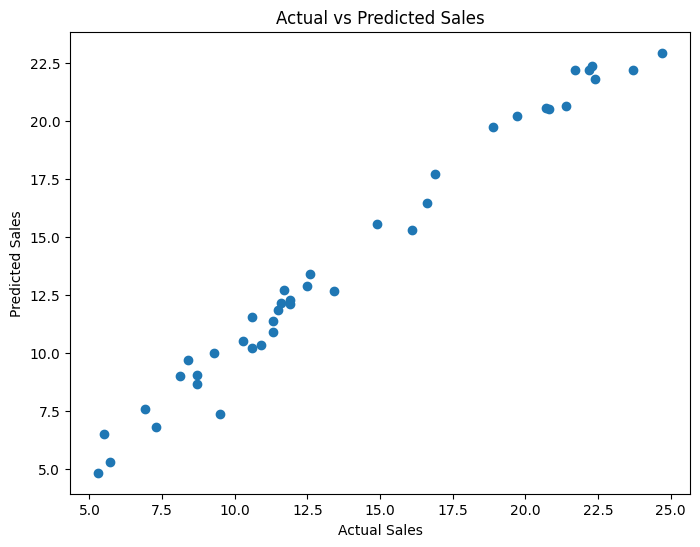

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Business Insights

1. Advertising expenditure has a measurable relationship with sales.
2. The advertising channel with the highest feature importance has the strongest contribution to the prediction model.
3. Businesses can prioritize advertising investment in the most influential channel.
4. The trained machine learning model can be used to estimate expected sales for different advertising budgets.
5. Data-driven advertising allocation can help businesses improve sales forecasting and marketing decisions.

In [31]:
import joblib

joblib.dump(rf_model, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [32]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

print("Columns after cleaning:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

Columns after cleaning:
['TV', 'Radio', 'Newspaper', 'Sales']

Dataset shape: (200, 4)


## Data Cleaning

The dataset was checked for missing values and duplicate records.

- No missing values were found.
- No duplicate rows were found.
- The `Unnamed: 0` column was removed because it is only an index column and does not contribute to sales prediction.
- The remaining columns were used for analysis and machine learning.

In [33]:
# Correlation of advertising channels with sales

sales_correlation = df[["TV", "Radio", "Newspaper", "Sales"]].corr()["Sales"]

print("Correlation with Sales:")
print(sales_correlation.sort_values(ascending=False))

Correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


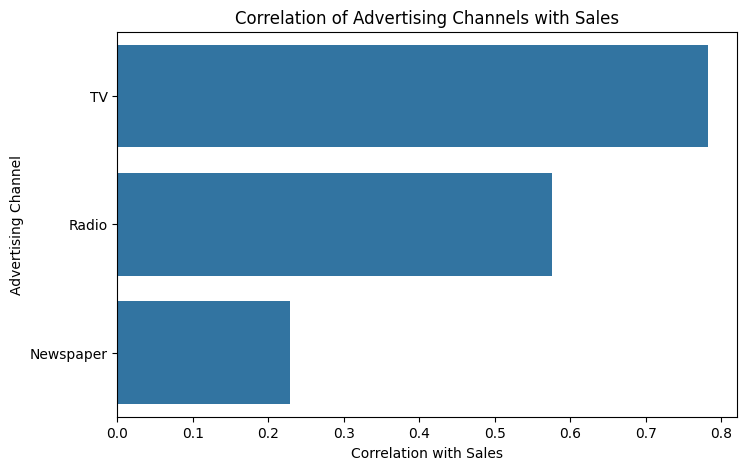

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sales_correlation.drop("Sales").values,
    y=sales_correlation.drop("Sales").index
)

plt.title("Correlation of Advertising Channels with Sales")
plt.xlabel("Correlation with Sales")
plt.ylabel("Advertising Channel")

plt.show()

## Feature Importance Analysis

The Random Forest model was used to identify the relative importance of the advertising channels.

- TV advertising has the highest importance at approximately 62.48%.
- Radio advertising has the second-highest importance at approximately 36.22%.
- Newspaper advertising has a much lower importance at approximately 1.30%.

Therefore, TV and Radio advertising are the most influential features for predicting sales in this dataset.

In [35]:
new_advertising = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = rf_model.predict(new_advertising)

print("Advertising Budget:")
print(new_advertising)

print("\nPredicted Sales:", round(predicted_sales[0], 2))

Advertising Budget:
    TV  Radio  Newspaper
0  150     30         20

Predicted Sales: 16.68


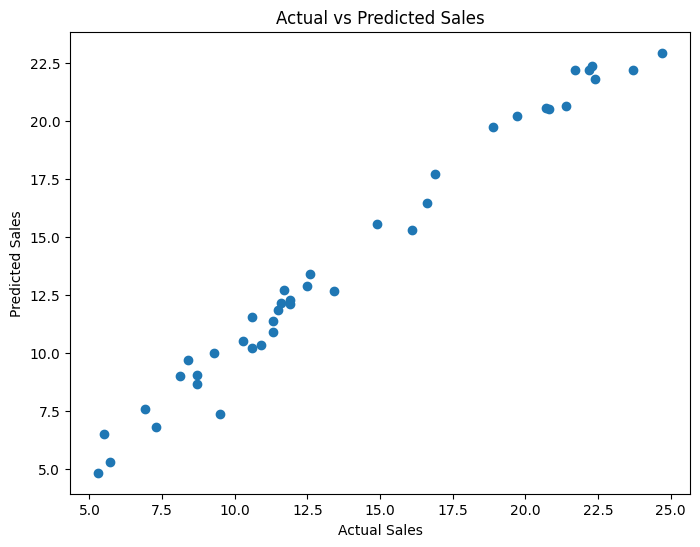

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Business Insights

1. **TV advertising is the most influential factor**
   - The Random Forest model gives TV advertising the highest feature importance of approximately 62.48%.

2. **Radio advertising also has a strong impact**
   - Radio has approximately 36.22% feature importance and contributes significantly to sales prediction.

3. **Newspaper advertising has limited predictive importance**
   - Newspaper has only approximately 1.30% feature importance compared with TV and Radio.

4. **Random Forest provides the best prediction performance**
   - The Random Forest model achieved an R² score of approximately 98.13%, outperforming Linear Regression and Decision Tree models.

5. **Marketing budget allocation can be data-driven**
   - Businesses can prioritize TV and Radio advertising when planning campaigns, while evaluating Newspaper spending carefully.

6. **Machine learning can support sales planning**
   - The trained model can estimate expected sales for different advertising budgets and help businesses make better marketing decisions.

## Conclusion

This project developed a machine learning system for predicting sales based on advertising expenditure across TV, Radio, and Newspaper channels.

After data cleaning, exploratory data analysis, feature analysis, and model development, three regression models were evaluated: Linear Regression, Decision Tree Regression, and Random Forest Regression.

Among the tested models, Random Forest achieved the best performance with an R² score of 0.9813, MAE of 0.6201, and RMSE of 0.7686.

The feature importance analysis showed that TV and Radio advertising were considerably more influential for sales prediction than Newspaper advertising.

The results demonstrate how machine learning can help businesses understand advertising effectiveness and support data-driven marketing and sales planning.